In [1]:
import sys, os; sys.path.insert(0, os.path.join("..", "src")) if os.path.basename(os.getcwd())=="notebooks" else sys.path.insert(0, "src")
import config, data_layer, econometrics as ek, validate, outputs

# FR05b — Neft-qaz bloku: hasilat həcmləri, ixrac qiymətləri və sektorun əlavə dəyəri

Neft-qaz sektorunun real artımı və deflyatoru bu dəftərdə **həcm və qiymət** kəmiyyətlərindən
qurulur: hasilat və ixrac həcmləri natural ölçüdə, ixrac qiymətləri isə dollarla götürülür,
onların hasili sektorun buraxılışını, buraxılışın əlavə dəyər payı isə sektorun ÜDM-ini verir.
Beləliklə real artım artıq kənardan verilən bir faiz rəqəmi deyil, hesablanan kəmiyyətdir.

## 1. Tələb

MİİS §15.5.1 neft-qaz sektorunun real artım tempini və deflyatorunu tələb edir. Paketin əvvəlki
buraxılışında bu iki göstərici belə qurulurdu:

| Göstərici | Əvvəlki buraxılış | Bu dəftər |
|---|---|---|
| `oil_realg` (real artım) | `assumptions.csv`-yə birbaşa yazılan ekzogen faiz rəqəmi — hasilat planının artım tempi | neft və qazın **əmtəəlik hasilat həcmlərinin** dəyər çəkili indeksi |
| `oil_defl` (deflyator) | Brent qiymətinin loq fərqi + məzənnə + 2022-ci il üçün süni dəyişən | neft və qazın ixrac qiymətlərinin **ixrac dəyəri ilə çəkilənmiş** indeksi (tənlik FR01-dədir) |

İki dəyişikliyin səbəbi eynidir. 2013-cü ildə qazın neft-qaz ixrac dəyərindəki payı 3,4 % idi,
2025-ci ildə 42,2 %-dir. Yalnız neft qiymətinə bağlı deflyator bu dəyişikliyi görmür və 2022-ci
ilin qaz epizodunu ancaq süni dəyişənlə "izah edə" bilir; yalnız plan rəqəmi kimi verilən real
artım isə hansı məhsulun həcminin nə qədər dəyişdiyini göstərmir.

**Hasilat planının statusu.** Nazirliyin hasilat planı **həcm planıdır** — 8 vərəq şablonunun
2.4.1.4. bölməsində neft və qaz hasilatı min ton və mln m³ ilə verilib. Bu dəftər həmin planı
proqnoz illəri üçün **həcm yolu** kimi işlədir; bu, planın öz ölçü vahidində, öz təyinatı üzrə
istifadəsidir. Plan eyni zamanda şablon-nümunə ssenarisi kimi müqayisə cədvəlində saxlanılır.
Rəsmi hasilat proqnozu və onun daxili/ixrac bölgüsü daxil olduqda həcm yolu birbaşa əvəzlənir —
blokun qalan hissəsinə toxunulmur.

## 2. Məlumat

Bütün sıralar əsas iş kitabının **Neft-Qaz sektoru** və **Mədənçıxarma** vərəqlərindən
`data_layer.oilgas_block()` vasitəsilə oxunur. Hər sıra üçün vərəq, sətir və **etiket** üçlüyü
yoxlanılır: sətir nömrəsi iş kitabının yeni buraxılışında sürüşərsə, blok işləmir, səhv sıra ilə
davam etmir.

| `series_code` | Göstərici | Vahid | Vərəq, sətir | Əhatə |
|---|---|---|---|---|
| `oilgas_r003` | Neft hasilatı | mln ton | Neft-Qaz sektoru, 3 | 1995–2025 |
| `oilgas_r004` | Əmtəəlik neft hasilatı | mln ton | Neft-Qaz sektoru, 4 | 2006–2025 |
| `oilgas_r005` | Neft ixracı | mln ton | Neft-Qaz sektoru, 5 | 1997–2025 |
| `oilgas_r006` | Neft ixracı | mln USD | Neft-Qaz sektoru, 6 | 1997–2025 |
| `oilgas_r010` | Neftin ixrac qiyməti | USD/barel | Neft-Qaz sektoru, 10 | 1997–2025 |
| `oilgas_r012` | Qaz hasilatı | mlrd m³ | Neft-Qaz sektoru, 12 | 1995–2025 |
| `oilgas_r013` | Əmtəəlik qaz hasilatı | mlrd m³ | Neft-Qaz sektoru, 13 | 2006–2025 |
| `oilgas_r014` | Qaz ixracı (DGK) | mlrd m³ | Neft-Qaz sektoru, 14 | 2006–2025 |
| `oilgas_r015` | Qaz ixracı (DGK) | mln USD | Neft-Qaz sektoru, 15 | 2006–2025 |
| `oilgas_r018` | Qazın ixrac qiyməti | USD/min m³ | Neft-Qaz sektoru, 18 | 2006–2025 |
| `mine_r008` | Xam neft və təbii qaz hasilatı üzrə buraxılış | mln AZN | Mədənçıxarma, 8 | 2016–2025 |
| `mine_r009` | Xam neft və təbii qaz hasilatı üzrə əlavə dəyər | mln AZN | Mədənçıxarma, 9 | 2016–2025 |

Daxili bazara verilən həcm **eyniliklə** hesablanır: `daxili = əmtəəlik − ixrac`. Eynilik hər il
üçün yoxlanılır (Bölmə 4).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import Markdown, display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True, "grid.alpha": 0.30,
                     "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110})

LA, FY = config.LAST_ACTUAL, list(config.FY)
FR = "FR5B"
WB = "Statistik data dinamika 05.06.2026 +.xlsx"
BBL = data_layer.BBL_PER_TON        # 7,4 barel/ton — iş kitabının öz konvensiyası

B = data_layer.oilgas_block()       # bütün blok bir cədvəldə (etiket yoxlaması daxildə)
print(f"blok əhatəsi: {int(B.index.min())}–{int(B.index.max())}, {B.shape[1]} sütun")
B.loc[2013:, ["q_oil_mkt", "q_oil_exp", "q_oil_dom", "q_gas_mkt", "q_gas_exp", "q_gas_dom",
              "p_oil_exp", "p_gas_exp", "w_oil_exp"]].round(3)

blok əhatəsi: 1991–2025, 22 sütun


,q_oil_mkt,q_oil_exp,q_oil_dom,q_gas_mkt,q_gas_exp,q_gas_dom,p_oil_exp,p_gas_exp,w_oil_exp
year,,,,,,,,,
2013,43.163,24.856,18.307,17.895,3.035,14.860,110.062,231.287,0.966
2014,41.952,23.612,18.340,18.826,1.826,17.001,105.335,166.886,0.984
2015,41.570,21.960,19.609,19.236,8.433,10.803,54.559,178.475,0.855
2016,40.999,34.096,6.903,18.718,8.396,10.322,42.379,130.620,0.907
2017,38.636,30.524,8.112,18.186,8.259,9.927,53.884,149.849,0.908
2018,38.722,29.482,9.240,19.207,8.040,11.167,72.011,188.098,0.912
2019,37.452,30.837,6.615,24.514,12.537,11.977,64.919,188.782,0.862
2020,34.465,29.023,5.442,26.487,12.424,14.063,43.598,176.307,0.810
2021,34.513,27.116,7.397,32.578,20.047,12.532,65.877,276.075,0.705


### 2.1. Sıraların özündəki iki uyğunsuzluq

İki məsələ məlumatın özündədir və hesabatda göstərilir.

**Neftin ixrac həcmi 2016-cı ilə qədər əmtəəlik hasilatla uzlaşmır.** 2008-ci il üçün iş kitabı
78,1 mln ton ixrac göstərir, halbuki həmin il əmtəəlik hasilat 44,4 mln tondur; eyniliklə
hesablanan daxili həcm mənfi çıxır. 2006–2015-ci illərdə isə daxili həcm 17–23 mln ton kimi
görünür ki, bu, daxili emal gücündən qat-qat böyükdür. Ona görə neft üzrə daxili/ixrac bölgüsü
**yalnız 2016-cı ildən etibarən** etibarlı sayılır. Qaz üzrə eynilik 2006-dan qapanır və
alınan daxili həcm (10–16 mlrd m³) daxili istehlakın məlum həcmi ilə uzlaşır.

**Ixrac qiyməti dəyər ÷ həcm nisbətidir.** İş kitabının 10-cu sətri həcm və dəyərdən 7,4 barel/ton
əmsalı ilə törədilib (bütün illərdə nisbət tam olaraq 7,4 verir), ona görə 2008-ci ilin həcm
qüsuru həmin ilin qiymətinə də keçir: 2008-də ixrac qiyməti 76,4 USD/barel, Brent isə
96,9 USD/bareldir. Bu səbəbdən **çəkili qiymət indeksinin neft ayağı Brent qiyməti ilə ölçülür**
(qazın ixrac qiyməti isə dəyər ÷ həcm nisbətindən asılı olmayan müstəqil sıradır və iş kitabının
15/14-cü sətirlərindən yenidən hesablandıqda 0,03 USD həddində üst-üstə düşür).

In [3]:
# ixrac qiymətinin dəyər ÷ həcm mənşəyi və qaz qiymətinin çarpaz yoxlanışı
impl_bbl = (B["v_oil_exp"] / B["q_oil_exp"] / B["p_oil_exp"]).dropna()
impl_gas = (B["v_gas_exp"] / B["q_gas_exp"]).dropna()
print(f"neft: dəyər ÷ (həcm × qiymət) nisbəti — min {impl_bbl.min():.4f}, maks {impl_bbl.max():.4f} "
      f"(iş kitabının 7,4 barel/ton konvensiyası)")
print(f"qaz : sətir 18 ilə dəyər ÷ həcm arasında maksimal fərq "
      f"{(B['p_gas_exp'] - impl_gas).abs().max():.3f} USD/min m³")
print(f"neftin ixrac qiyməti ÷ Brent: 2011–{LA} ortası "
      f"{(B['p_oil_exp'] / B['p_brent']).loc[2011:].mean():.4f}, "
      f"2008-ci ildə {(B['p_oil_exp'] / B['p_brent']).loc[2008]:.4f} (kənar müşahidə)")

neft: dəyər ÷ (həcm × qiymət) nisbəti — min 7.4000, maks 7.4002 (iş kitabının 7,4 barel/ton konvensiyası)
qaz : sətir 18 ilə dəyər ÷ həcm arasında maksimal fərq 0.027 USD/min m³
neftin ixrac qiyməti ÷ Brent: 2011–2025 ortası 1.0098, 2008-ci ildə 0.7886 (kənar müşahidə)


## 3. Model seçimi

Blok dörd hissədən ibarətdir.

1. **Həcm.** Neft (mln ton) və qaz (mlrd m³) birbaşa toplana bilməz; onları toplanan edən çəki
   dəyərdir. Ona görə real artım əvvəlki ilin manatla ixrac qiymətləri ilə çəkilənmiş **Laspeyres
   həcm indeksi** kimi hesablanır. Baza kəmiyyət **əmtəəlik hasilatdır**: hesablarda əlavə dəyər
   məhz əmtəəlik məhsuldan yaranır.
2. **Qiymət.** Deflyatorun əsası ixrac dəyəri ilə çəkilənmiş, zəncirlənmiş neft+qaz qiymət
   indeksidir. Çəki gecikmiş götürülür ki, cari ilin qiymət hərəkəti öz çəkisini özü təyin etməsin.
3. **Əlavə dəyər payı ρ.** Mədənçıxarma vərəqinin 8 və 9-cu sətirləri xam neft və qaz hasilatı
   üzrə buraxılışı və əlavə dəyəri ayrıca verir; ρ = əlavə dəyər ÷ buraxılış müşahidə olunan
   kəmiyyətdir və 2016–2025-ci illərdə 0,91–0,94 aralığındadır.
4. **Proqnoz girişləri.** Həcm yolu hasilat planından, Brent yolu FR05-dən, qazın ixrac qiyməti
   isə bu dəftərdə qurulan modeldən gəlir; qaz qiyməti üçün modellər geriyə doğru sınaqda
   müqayisə edilir və yalnız etalonu üstələyənlər saxlanılır (§D4).

Ölçü vahidlərinin uzlaşdırılması: neftin ixrac dəyəri = həcm (mln ton) × 7,4 × qiymət (USD/barel);
qazın ixrac dəyəri = həcm (mlrd m³) × qiymət (USD/min m³) — hər ikisi mln USD verir.

## 4. Testlər

In [4]:
# 4.1 EYNİLİK: daxili = əmtəəlik − ixrac, HƏR il üçün (D4)
oil_id = B.dropna(subset=["q_oil_mkt", "q_oil_exp", "q_oil_dom"])
gas_id = B.dropna(subset=["q_gas_mkt", "q_gas_exp", "q_gas_dom"])
validate.identity_check("neft: əmtəəlik = daxili + ixrac",
                        oil_id["q_oil_mkt"], oil_id["q_oil_dom"] + oil_id["q_oil_exp"],
                        tol=1e-9, verbose=True)
validate.identity_check("qaz: əmtəəlik = daxili + ixrac",
                        gas_id["q_gas_mkt"], gas_id["q_gas_dom"] + gas_id["q_gas_exp"],
                        tol=1e-9, verbose=True)

# 4.2 EYNİLİK: ixrac dəyəri = həcm × qiymət (iş kitabının öz sətirləri arasında)
vo = (B["q_oil_exp"] * BBL * B["p_oil_exp"]).dropna()
vg = (B["q_gas_exp"] * B["p_gas_exp"]).dropna()
print(f"\nneftin ixrac dəyəri — sətir 6 ilə həcm×qiymət arasında maksimal nisbi fərq: "
      f"{((vo / B['v_oil_exp'].reindex(vo.index) - 1).abs().max() * 100):.4f} %")
print(f"qazın ixrac dəyəri — sətir 15 ilə həcm×qiymət arasında maksimal nisbi fərq: "
      f"{((vg / B['v_gas_exp'].reindex(vg.index) - 1).abs().max() * 100):.4f} %")

# 4.3 daxili həcmin etibarlılıq sərhədi açıq göstərilir
neg = B.index[(B["q_oil_dom"] < 0)].tolist()
big = B.index[(B["q_oil_dom"] > 12)].tolist()
print(f"\nDATA-GAP: neft üzrə daxili həcm mənfi çıxan illər: {neg}; "
      f"12 mln tondan böyük çıxan illər: {big} → bölgü 2016-dan etibarlı sayılır")

[PASS] eynilik «neft: əmtəəlik = daxili + ixrac»: 20 il, maksimal mütləq fərq 0.000e+00 (2006), dözüm 1.0e-09
[PASS] eynilik «qaz: əmtəəlik = daxili + ixrac»: 20 il, maksimal mütləq fərq 0.000e+00 (2006), dözüm 1.0e-09

neftin ixrac dəyəri — sətir 6 ilə həcm×qiymət arasında maksimal nisbi fərq: 0.0033 %
qazın ixrac dəyəri — sətir 15 ilə həcm×qiymət arasında maksimal nisbi fərq: 0.0076 %

DATA-GAP: neft üzrə daxili həcm mənfi çıxan illər: [2008]; 12 mln tondan böyük çıxan illər: [2006, 2007, 2009, 2010, 2011, 2012, 2013, 2014, 2015] → bölgü 2016-dan etibarlı sayılır


## 5. Qiymətləndirmə

### 5.1. Çəkilər və çəkili qiymət indeksi

In [5]:
# ixrac dəyərində qazın payı — dəyişikliyin özü bu cədvəldədir
wtab = pd.DataFrame({
    "neftin ixrac dəyəri, mln USD": B["v_oil_exp"], "qazın ixrac dəyəri, mln USD": B["v_gas_exp"],
    "qazın payı, %": (1 - B["w_oil_exp"]) * 100,
}).loc[2006:]
print(f"qazın ixrac dəyərindəki payı: 2013 = {(1 - B['w_oil_exp'].loc[2013]) * 100:.1f} %, "
      f"{LA} = {(1 - B['w_oil_exp'].loc[LA]) * 100:.1f} %")
wtab.round(1)

qazın ixrac dəyərindəki payı: 2013 = 3.4 %, 2025 = 42.2 %


,"neftin ixrac dəyəri, mln USD","qazın ixrac dəyəri, mln USD","qazın payı, %"
year,,,
2006,3848.5,3.2,0.1
2007,3214.2,18.1,0.6
2008,44170.9,73.9,0.2
2009,11989.7,125.3,1.0
2010,18489.6,288.5,1.5
2011,22911.0,574.6,2.4
2012,20232.6,648.7,3.1
2013,20244.1,702.0,3.4
2014,18404.9,304.7,1.6


In [6]:
# çəkili (zəncirlənmiş) qiymət indeksinin artımı — neft ayağı Brent ilə
dpw = data_layer.oilgas_price_growth("brent").rename("dpw")
dlb = (np.log(B["p_brent"]).diff() * 100).rename("dlb")
dpw_real = data_layer.oilgas_price_growth("realised").rename("dpw_real")
cmp_ix = pd.DataFrame({"Δln Brent, %": dlb, "çəkili indeks (Brent ayağı), %": dpw,
                       "çəkili indeks (faktiki ixrac qiyməti), %": dpw_real}).loc[2007:]
print("2022-ci il: Brent +{:.1f} %, çəkili indeks +{:.1f} % — fərq qazın payındandır"
      .format(dlb.loc[2022], dpw.loc[2022]))
cmp_ix.round(2)

2022-ci il: Brent +35.4 %, çəkili indeks +84.9 % — fərq qazın payındandır


,"Δln Brent, %","çəkili indeks (Brent ayağı), %","çəkili indeks (faktiki ixrac qiyməti), %"
2007,10.59,11.28,22.01
2008,29.13,34.00,11.43
2009,-45.12,-36.26,-23.81
2010,25.42,28.50,33.96
2011,33.47,39.51,41.85
2012,0.33,0.82,1.81
2013,-2.79,-2.77,-2.43
2014,-9.25,-9.47,-5.08
2015,-63.74,-46.25,-47.31
2016,-18.14,-18.07,-22.98


### 5.2. Qazın ixrac qiyməti — proqnoz üfüqü üçün model

Qazın ixrac qiymətinin irəli yolu heç bir mənbədə verilmir və onu birbaşa Brent-dən çıxarmaq
mümkün deyil: qaz/neft nisbi ixrac qiyməti 2013-cü ildə 2,10, 2025-ci ildə 5,01-dir. Ona görə
dörd namizəd model geriyə doğru sınaqda müqayisə edilir və yalnız etalonu (təsadüfi gəzişməni)
üstələyənlər saxlanılır.

**Dəstəkləyici sübut — müqavilə səviyyəsində qiymətlər.** Nazirliyin öz nümunə iş kitabı
(MOE OIL.xlsx, `O&G` vərəqi) qaz ixrac qiymətini iki ayrı sətirdə saxlayır: Şahdəniz üzrə
(sətir 54) və SOCAR üzrə (sətir 55). Bu iki rejim eyni istiqamətdə hərəkət etmir. Sıralar
**modelə daxil edilmir** — fayl nümunə-model faylıdır və onun 2024-dən sonrakı sütunları
proyeksiyadır, ona görə burada yalnız faktiki dövr (≤2024) oxunur və yalnız arqumentin
sənədləşdirilməsi üçün çap olunur.

In [7]:
# YALNIZ OXUNUR — dəstəkləyici sübut, modelin girişi deyil (provenans aşağıda çap olunur)
moe = data_layer.moe_gas_contract_prices()
moe["SD ÷ SOCAR"] = moe["sd_usd_km3"] / moe["socar_usd_km3"]
moe["iş kitabının ixrac qiyməti (sətir 18)"] = B["p_gas_exp"].reindex(moe.index)
moe["iş kitabı ÷ SD"] = moe["iş kitabının ixrac qiyməti (sətir 18)"] / moe["sd_usd_km3"]
print(data_layer.OILGAS_MOE_SOURCE_NOTE)
print(f"\niki müqavilə rejiminin nisbəti: 2018-də {moe.loc[2018, 'SD ÷ SOCAR']:.2f}, "
      f"2022-də {moe.loc[2022, 'SD ÷ SOCAR']:.2f} — yəni 2022-ci ilin qiymət epizodu bütün qaz "
      f"ixracına deyil, BİR müqavilə rejiminə aiddir")
print(f"iş kitabının orta ixrac qiyməti Şahdəniz sırasına yaxındır: nisbətin "
      f"2018-{int(moe.index.max())} aralığı {moe['iş kitabı ÷ SD'].min():.2f}-"
      f"{moe['iş kitabı ÷ SD'].max():.2f} — modelləşdirilən sıra praktik olaraq həmin rejimi izləyir")
moe.round(2)

MOE OIL.xlsx, `O&G` vərəqi, sətir 54 (SD — Şahdəniz) və 55 (SOCAR), USD/min m³; Nazirliyin nümunə-model faylı — YALNIZ OXUNUR, yalnız faktiki sütunlar (≤2024)

iki müqavilə rejiminin nisbəti: 2018-də 0.98, 2022-də 4.14 — yəni 2022-ci ilin qiymət epizodu bütün qaz ixracına deyil, BİR müqavilə rejiminə aiddir
iş kitabının orta ixrac qiyməti Şahdəniz sırasına yaxındır: nisbətin 2018-2024 aralığı 0.83-1.25 — modelləşdirilən sıra praktik olaraq həmin rejimi izləyir


,sd_usd_km3,socar_usd_km3,SD ÷ SOCAR,iş kitabının ixrac qiyməti (sətir 18),iş kitabı ÷ SD
2018,161.00,163.90,0.98,188.10,1.17
2019,189.28,165.84,1.14,188.78,1.00
2020,211.63,155.09,1.36,176.31,0.83
2021,291.60,150.94,1.93,276.08,0.95
2022,786.60,190.21,4.14,790.38,1.00
2023,411.69,199.72,2.06,513.77,1.25
2024,326.69,181.65,1.80,326.19,1.00


Cədvəl çəkili qiymət indeksinin arqumentini rəqəmlə göstərir. 2022-ci ildə Şahdəniz üzrə qiymət SOCAR-ın öz satış
qiymətindən dörd dəfədən çox yuxarı olub; iş kitabının modelləşdirilən orta ixrac qiyməti isə
Şahdəniz sırasına yaxın gedir. Yəni 2022-ci ilin epizodu neft bazarının deyil, **bir qaz müqaviləsi
rejiminin** hadisəsidir — köhnə spesifikasiyada onu yalnız süni dəyişənlə "izah etmək" mümkün
olmasının səbəbi budur. Çəkili qiymət indeksi həmin hadisəni qazın öz qiyməti və öz ixrac dəyəri
payı vasitəsilə birbaşa daşıyır, ona görə süni dəyişənə ehtiyac qalmır (FR01, Bölmə 5.1).

In [8]:
GP = pd.DataFrame({"y": B["p_gas_exp"], "lb": np.log(B["p_brent"])}).dropna()


def gp_ar1(train, t):
    s = np.log(train["y"].dropna())
    if len(s) < 6:
        return np.nan
    d = pd.DataFrame({"y": s, "l1": s.shift(1)}).dropna()
    f = sm.OLS(d["y"], sm.add_constant(d[["l1"]], has_constant="add")).fit()
    return float(np.exp(f.params["const"] + f.params["l1"] * s.iloc[-1]))


def gp_ratio5(train, t):
    r = (train["y"] / np.exp(train["lb"])).dropna()
    if len(r) < 5:
        return np.nan
    return float(r.iloc[-5:].mean() * np.exp(GP.at[t, "lb"]))


def gp_ratio_full(train, t):
    r = (train["y"] / np.exp(train["lb"])).dropna()
    if len(r) < 5:
        return np.nan
    return float(r.mean() * np.exp(GP.at[t, "lb"]))


def gp_ecm(train, t):
    d = pd.DataFrame({"y": np.log(train["y"]), "lb": train["lb"]}).dropna()
    if len(d) < 10:
        return np.nan
    try:
        e = ek.ardl_ecm(d["y"], d[["lb"]], maxlags=1, verbose=False)
        return float(np.exp(e.predict_next(float(d["y"].iloc[-1]), {"lb": float(d["lb"].iloc[-1])},
                                           {"lb": float(GP.at[t, "lb"])})))
    except Exception:
        return np.nan


bt_gp = ek.backtest(GP, {"AR1": gp_ar1, "NISBET_5IL": gp_ratio5, "NISBET_TAM": gp_ratio_full,
                         "ECM": gp_ecm},
                    min_train=8, series_code="oilgas_p_gas_exp", verbose=True)
pd.DataFrame({"OOS RMSE, USD/min m³": bt_gp.rmse,
              "etalonu üstələyir": pd.Series(bt_gp.beats_rw),
              "80 % əhatə": bt_gp.coverage80}).round(3)

[SINAQ] Geriyə doğru sınaq (oilgas_p_gas_exp): ümumi pəncərə 2018–2025 (8 il), RW RMSE = 220.327, ansambl RMSE = 190.344; bacarıq = 14%. Saxlanılan modellər: AR1 (çəki 0.29), NISBET_5IL (çəki 0.40), ECM (çəki 0.31).


,"OOS RMSE, USD/min m³",etalonu üstələyir,80 % əhatə
AR1,209.029,True,0.875
ECM,200.542,True,0.875
NISBET_5IL,176.034,True,0.875
NISBET_TAM,227.657,False,0.875
RW,220.327,NaN,0.875


In [9]:
# saxlanılan modellərin yolları (proqnoz Bölmə 7-də qurulur, burada tənliklər sabitlənir)
_lg = np.log(GP["y"])
_d = pd.DataFrame({"y": _lg, "l1": _lg.shift(1)}).dropna()
res_gp_ar1 = ek.ols_hac(_d["y"], _d[["l1"]], maxlags=1,
                        name="qazın ixrac qiyməti — AR(1), loq səviyyə")
ecm_gp = ek.ardl_ecm(GP["y"].pipe(np.log), GP[["lb"]], maxlags=1,
                     name="qazın ixrac qiyməti — ECM (ln qaz ~ ln Brent)", verbose=True)
ratio5_gp = float((GP["y"] / np.exp(GP["lb"])).iloc[-5:].mean())
print(f"\nqaz/Brent nisbətinin son 5 illik ortası: {ratio5_gp:.4f} "
      f"(USD/min m³ ÷ USD/barel); {LA} nisbəti {float(GP['y'].iloc[-1] / np.exp(GP['lb'].iloc[-1])):.4f}")
print(res_gp_ar1)

[OLS+HAC] qazın ixrac qiyməti — AR(1), loq səviyyə: n=19, nümunə=2007–2025, R²=0.503, düzəldilmiş R²=0.474, s.x.=0.3391
[ECM] Kointeqrasiya (qazın ixrac qiyməti — ECM (ln qaz ~ ln Brent)): EG statistikası -0.000, p = 0.986 (n = 20) → uzunmüddətli əlaqə təsdiqlənmir, tənlik fərqlər (Δ) səviyyəsində qurulur.
[OLS+HAC] qazın ixrac qiyməti — ECM (ln qaz ~ ln Brent) — uzunmüddətli: n=20, nümunə=2006–2025, R²=0.146, düzəldilmiş R²=0.099, s.x.=0.5391
[OLS+HAC] qazın ixrac qiyməti — ECM (ln qaz ~ ln Brent) — ECM: n=19, nümunə=2007–2025, R²=0.511, düzəldilmiş R²=0.450, s.x.=0.3010

qaz/Brent nisbətinin son 5 illik ortası: 5.4143 (USD/min m³ ÷ USD/barel); 2025 nisbəti 5.0651
OLS+HAC[qazın ixrac qiyməti — AR(1), loq səviyyə]  n=19  nümunə=2007–2025  HAC gecikmə=1
  R²=0.503  düzəldilmiş R²=0.474  reqressiyanın s.x.=0.3391
  dəyişən                əmsal    HAC s.x.        t        p
  const                 2.3136      0.4890     4.73    0.000
  l1                    0.5829      0.0968     6.02    

### 5.3. Əlavə dəyərin buraxılışdakı payı ρ

In [10]:
rho = B["rho"].dropna()
print(f"ρ = əlavə dəyər ÷ buraxılış, {int(rho.index.min())}–{int(rho.index.max())} "
      f"(n = {len(rho)}): orta {rho.mean():.4f}, min {rho.min():.4f}, maks {rho.max():.4f}")
RHO_FC = float(rho.iloc[-3:].mean())      # son üç ilin ortası — proqnoz üfüqü üçün sabit
print(f"proqnoz üfüqü üçün ρ = son üç ilin ortası = {RHO_FC:.4f}")
print("\nqeyd: `mine_r008` 2018-ci il üçün boşdur, ona görə həmin il ρ hesablanmır.")
rho.round(4).to_frame("ρ").T

ρ = əlavə dəyər ÷ buraxılış, 2016–2025 (n = 9): orta 0.9265, min 0.9102, maks 0.9426
proqnoz üfüqü üçün ρ = son üç ilin ortası = 0.9165

qeyd: `mine_r008` 2018-ci il üçün boşdur, ona görə həmin il ρ hesablanmır.


year,2016,2017,2019,2020,2021,2022,2023,2024,2025
ρ,0.938,0.9303,0.9402,0.9127,0.9254,0.9426,0.9277,0.9102,0.9114


### 5.4. Həcm indeksindən real artıma

Laspeyres həcm indeksi (əvvəlki ilin manatla ixrac qiymətləri ilə) hesablanır və nəşr olunmuş
neft-qaz real artımı ilə tutuşdurulur. Nəşr olunmuş sıra 2013-cü ildən statutar şablondan,
2001–2012-ci illər üçün isə iş kitabının Real sektor blokundan götürülür (FR01-in birləşdirmə
qaydası ilə eyni).

In [11]:
gv = data_layer.oilgas_volume_growth().rename("gv")
oil_g_pub = data_layer.actuals("oil_realg")
_wb = data_layer.wb_annual("real_r008") - 100.0
oil_g_wb = _wb[_wb.index <= LA]
oil_g = pd.concat([oil_g_wb.loc[2001:2012], oil_g_pub]).sort_index().rename("y")

VG = pd.DataFrame({"y": oil_g, "gv": gv}).dropna()
res_vg = ek.ols_hac(VG["y"], VG[["gv"]], maxlags=1,
                    name="neft-qaz real artımı ~ əmtəəlik həcm indeksi")
print(res_vg)
print(f"\nsıranın standart kənarlanması {VG['y'].std():.3f} f.b.; "
      f"tənliyin standart xətası {res_vg.sigma:.3f} f.b.")
pd.DataFrame({"nəşr olunmuş real artım, %": VG["y"], "həcm indeksi, %": VG["gv"],
              "fərq, f.b.": VG["y"] - VG["gv"]}).round(3)

[OLS+HAC] neft-qaz real artımı ~ əmtəəlik həcm indeksi: n=19, nümunə=2007–2025, R²=0.972, düzəldilmiş R²=0.970, s.x.=1.6974
OLS+HAC[neft-qaz real artımı ~ əmtəəlik həcm indeksi]  n=19  nümunə=2007–2025  HAC gecikmə=1
  R²=0.972  düzəldilmiş R²=0.970  reqressiyanın s.x.=1.6974
  dəyişən                əmsal    HAC s.x.        t        p
  const                -0.1517      0.4381    -0.35    0.729
  gv                    1.0772      0.0368    29.24    0.000

sıranın standart kənarlanması 9.879 f.b.; tənliyin standart xətası 1.697 f.b.


,"nəşr olunmuş real artım, %","həcm indeksi, %","fərq, f.b."
2007,36.800,33.105,3.695
2008,6.800,7.031,-0.231
2009,14.000,11.891,2.109
2010,1.800,0.834,0.966
2011,-9.300,-9.768,0.468
2012,-5.000,-4.418,-0.582
2013,1.004,0.767,0.237
2014,-2.930,-1.960,-0.969
2015,1.176,-0.642,1.818
2016,-0.022,-1.597,1.575


Əmsal 1,077, sabit hədd isə sıfırdan fərqli deyil (p = 0,73). Yəni hesabların neft-qaz real artımı
əmtəəlik həcm indeksinin praktik olaraq **birə-bir** funksiyasıdır — bu, blokun qurulmasının
doğruluğunun ən sadə göstəricisidir. Aşağıda hər iki oxunuş (təmiz eynilik və kalibrlənmiş tənlik)
ayrıca model kimi sınaqdan keçirilir.

## 6. Geriyə doğru sınaq

Sınaq bir addımlıq və genişlənən pəncərəlidir: hər il üçün model yalnız ondan əvvəlki illərin
məlumatı ilə qiymətləndirilir. **Şərtlilik açıq deyilir:** həcm indeksi cari ilin həcmlərindən
qurulur, yəni sınaq "həcm yolu bilindiyi halda real artım nə qədər dəqiq alınır" sualına cavab
verir. Bu, deflyatorun Brent yoluna şərtli olması ilə eyni məntiqdir. Həcm yolunun öz
qeyri-müəyyənliyi ayrıca məsələdir və məhz ona görə rəsmi hasilat proqnozu məlumat sorğusundadır.

In [12]:
def vg_ident(train, t):
    return float(VG.at[t, "gv"])


def vg_struct(train, t):
    d = train.dropna()
    if len(d) < 8:
        return np.nan
    f = sm.OLS(d["y"], sm.add_constant(d[["gv"]], has_constant="add")).fit()
    return float(f.params["const"] + f.params["gv"] * VG.at[t, "gv"])


def m_ar1(train, t):
    d = pd.DataFrame({"y": train["y"], "l1": train["y"].shift(1)}).dropna()
    if len(d) < 8:
        return np.nan
    f = sm.OLS(d["y"], sm.add_constant(d[["l1"]], has_constant="add")).fit()
    return float(f.params["const"] + f.params["l1"] * float(train["y"].dropna().iloc[-1]))


def m_orta5(train, t):
    return float(train["y"].dropna().iloc[-5:].mean())


bt_og = ek.backtest(VG, {"HECM_EYNILIK": vg_ident, "HECM_STRUKTUR": vg_struct,
                         "AR1": m_ar1, "ORTA5": m_orta5},
                    min_train=8, series_code="oil_realg", verbose=True)
pd.DataFrame({"OOS RMSE, f.b.": bt_og.rmse, "etalonu üstələyir": pd.Series(bt_og.beats_rw),
              "80 % əhatə": bt_og.coverage80, "ansambl çəkisi": pd.Series(bt_og.weights)}).round(3)

[SINAQ] Geriyə doğru sınaq (oil_realg): ümumi pəncərə 2016–2025 (10 il), RW RMSE = 4.493, ansambl RMSE = 1.423; bacarıq = 68%. Saxlanılan modellər: HECM_EYNILIK (çəki 0.40), HECM_STRUKTUR (çəki 0.30), AR1 (çəki 0.14), ORTA5 (çəki 0.16).


,"OOS RMSE, f.b.",etalonu üstələyir,80 % əhatə,ansambl çəkisi
AR1,3.077,True,0.7,0.143
HECM_EYNILIK,1.839,True,0.9,0.400
HECM_STRUKTUR,2.134,True,0.9,0.297
ORTA5,2.909,True,0.7,0.160
RW,4.493,NaN,0.8,NaN


Dörd modelin hamısı təsadüfi gəzişməni üstələyir; ən yaxşısı təmiz həcm eyniliyidir. Ansamblın
etalona nisbətdə bacarığı sınaq pəncərəsində **68 %**-dir (2016–2025, RW RMSE 4,49 → ansambl 1,42) — yəni real artımı həcmdən
qurmaq, onu keçmiş artımın davamı kimi götürməkdən əhəmiyyətli dərəcədə dəqiqdir. Köhnə
buraxılışda bu göstərici üçün heç bir sınaq rəqəmi yox idi, çünki ekzogen fərziyyənin sınağı
mümkün deyil.

## 7. Proqnoz 2026–2030

### 7.1. Həcm yolu

In [13]:
A = outputs.read_assumptions()
for need in ("brent_usd", "usd_azn"):
    if need not in A:
        raise KeyError(f"'{need}' fərziyyə açarı yoxdur — yuxarı axın mərhələsi (FR05/FR10) işləməyib")
brent_fc = A["brent_usd"].reindex(FY)
fx_fc = A["usd_azn"].reindex(FY)

# hasilat planı — 8 vərəq şablonunun 2.4.1.4. bölməsi (HƏCM planı, öz ölçü vahidində)
plan_oil = data_layer.vereq_baseline("2.4.1.4.", "Neft hasilatı", row=35) / 1000.0      # mln ton
plan_gasm = data_layer.vereq_baseline("2.4.1.4.", "əmtəəlik qaz", row=37) / 1000.0      # mlrd m³
plan_gasp = data_layer.vereq_baseline("2.4.1.4.", "Qaz hasilatı", row=36) / 1000.0      # mlrd m³

# əmtəəlik neft: hasilat planı × əmtəəlik payı (son beş ilin ortası; pay 0,998 ətrafında sabitdir)
mkt_share = float((B["q_oil_mkt"] / B["q_oil_prod"]).loc[LA - 4:LA].mean())
q_oil_mkt_fc = (plan_oil * mkt_share).reindex(FY)
q_gas_mkt_fc = plan_gasm.reindex(FY)

# daxili həcmlər son faktiki ildə saxlanılır (açıq fərziyyə), ixrac qalıq kimi alınır
Q_OIL_DOM_FC = float(B["q_oil_dom"].loc[LA])
Q_GAS_DOM_FC = float(B["q_gas_dom"].loc[LA])
q_oil_exp_fc = q_oil_mkt_fc - Q_OIL_DOM_FC
q_gas_exp_fc = q_gas_mkt_fc - Q_GAS_DOM_FC

print(f"əmtəəlik neft payı (son 5 il ortası): {mkt_share:.4f}")
print(f"daxili həcm fərziyyəsi: neft {Q_OIL_DOM_FC:.3f} mln ton, qaz {Q_GAS_DOM_FC:.3f} mlrd m³ "
      f"({LA} səviyyəsində saxlanılır)")
vol_tbl = pd.DataFrame({
    "hasilat planı — neft, mln ton": plan_oil.reindex(FY),
    "əmtəəlik neft, mln ton": q_oil_mkt_fc, "neft ixracı, mln ton": q_oil_exp_fc,
    "hasilat planı — qaz, mlrd m³": plan_gasp.reindex(FY),
    "əmtəəlik qaz, mlrd m³": q_gas_mkt_fc, "qaz ixracı, mlrd m³": q_gas_exp_fc,
})
vol_tbl.round(3)

əmtəəlik neft payı (son 5 il ortası): 0.9978
daxili həcm fərziyyəsi: neft 4.235 mln ton, qaz 13.694 mlrd m³ (2025 səviyyəsində saxlanılır)


,"hasilat planı — neft, mln ton","əmtəəlik neft, mln ton","neft ixracı, mln ton","hasilat planı — qaz, mlrd m³","əmtəəlik qaz, mlrd m³","qaz ixracı, mlrd m³"
year,,,,,,
2026,27.639,27.579,23.344,48.437,38.008,24.314
2027,27.068,27.009,22.774,47.924,36.658,22.963
2028,26.593,26.535,22.300,45.667,34.533,20.839
2029,27.392,27.332,23.097,48.063,36.985,23.290
2030,27.283,27.223,22.989,48.054,36.529,22.834


### 7.2. Qiymət yolu və çəkilər

In [14]:
# qazın ixrac qiyməti — sınaqda saxlanılan modellərin çəkili birləşməsi
gp_paths = {}
_prev = float(np.log(GP["y"].iloc[-1]))
gp_paths["AR1"] = {}
for y in FY:
    _prev = float(res_gp_ar1.params["const"] + res_gp_ar1.params["l1"] * _prev)
    gp_paths["AR1"][y] = float(np.exp(_prev))
gp_paths["NISBET_5IL"] = {y: ratio5_gp * float(brent_fc.loc[y]) for y in FY}
gp_paths["NISBET_TAM"] = {y: float((GP["y"] / np.exp(GP["lb"])).mean() * brent_fc.loc[y]) for y in FY}
_py, _px = float(np.log(GP["y"].iloc[-1])), float(GP["lb"].iloc[-1])
gp_paths["ECM"] = {}
for y in FY:
    _py = float(ecm_gp.predict_next(_py, {"lb": _px}, {"lb": float(np.log(brent_fc.loc[y]))}))
    _px = float(np.log(brent_fc.loc[y]))
    gp_paths["ECM"][y] = float(np.exp(_py))
gp_paths["RW"] = {y: float(GP["y"].iloc[-1]) for y in FY}

p_gas_fc = bt_gp.combine(gp_paths).rename("qazın ixrac qiyməti")
p_oil_fc = brent_fc.copy()          # çəkili indeksin neft ayağı: FR05-in Brent yolu (tərifə görə)

# Buraxılışın manatla dəyərləndirilməsi üçün FAKTİKİ ixrac qiyməti lazımdır. Tarixi hissə iş
# kitabının öz ixrac qiyməti sırasıdır; proqnozda o, Brent-dən sabit nisbətlə alınır — nisbət
# 2011-ci ildən bəri 1,01 ətrafında dayanıqlıdır (2.1 bölməsində çap olunub). Nisbət tətbiq
# olunmasaydı, 2025 (faktiki qiymət) ilə 2026 (Brent) arasında qiymət bazası sınardı — D5-in
# qadağan etdiyi növ sınıq.
RATIO_OIL_EXP = float((B["p_oil_exp"] / B["p_brent"]).loc[LA - 4:LA].mean())
p_oil_exp_fc = (brent_fc * RATIO_OIL_EXP).rename("neftin ixrac qiyməti")
print(f"neftin ixrac qiyməti ÷ Brent, son 5 ilin ortası: {RATIO_OIL_EXP:.4f} "
      f"(sınaq: nisbətin {LA} dəyəri {float(B['p_oil_exp'].loc[LA] / B['p_brent'].loc[LA]):.4f})")

price_tbl = pd.DataFrame(gp_paths).loc[FY].round(1)
price_tbl["MƏRKƏZİ (ansambl)"] = p_gas_fc.round(1)
price_tbl["Brent, USD/barel"] = brent_fc.round(2)
price_tbl

neftin ixrac qiyməti ÷ Brent, son 5 ilin ortası: 0.9982 (sınaq: nisbətin 2025 dəyəri 1.0107)


,AR1,NISBET_5IL,NISBET_TAM,ECM,RW,MƏRKƏZİ (ansambl),"Brent, USD/barel"
2026,307.5,373.5,218.2,305.7,350.2,333.5,68.98
2027,285.0,373.4,218.2,281.5,350.2,319.6,68.97
2028,272.7,375.8,219.6,268.6,350.2,313.0,69.40
2029,265.8,376.1,219.7,260.6,350.2,308.6,69.46
2030,261.8,374.6,218.9,255.0,350.2,305.2,69.19


In [15]:
# tarixi + proqnoz qiymət və çəki sıraları bir zəncirdə
p_oil_all = pd.concat([B["p_brent"].dropna(), p_oil_fc]).sort_index()
p_gas_all = pd.concat([B["p_gas_exp"].dropna(), p_gas_fc]).sort_index()
fx_all = pd.concat([B["fx_avg"].dropna(), fx_fc]).sort_index()

# proqnoz illərinin ixrac dəyərləri (mln USD) → çəkilər
v_oil_fc = q_oil_exp_fc * BBL * p_oil_exp_fc
v_gas_fc = q_gas_exp_fc * p_gas_fc
w_all = pd.concat([B["w_oil_exp"].dropna(),
                   (v_oil_fc / (v_oil_fc + v_gas_fc)).rename("w_oil_exp")]).sort_index()

dpw_all = data_layer.weighted_price_growth(p_oil_all, p_gas_all, w_all)
dpw_fc = dpw_all.reindex(FY)
print("çəkili qiymət indeksinin artımı, proqnoz üfüqü:")
pd.DataFrame({"çəkili indeks, %": dpw_fc,
              "Δln Brent, %": (np.log(p_oil_all).diff() * 100).reindex(FY),
              "qazın ixrac dəyərindəki payı, %": (1 - w_all.reindex(FY)) * 100}).round(2)

çəkili qiymət indeksinin artımı, proqnoz üfüqü:


,"çəkili indeks, %","Δln Brent, %","qazın ixrac dəyərindəki payı, %"
2026,-2.14,-0.23,40.54
2027,-1.71,-0.01,38.74
2028,-0.41,0.62,36.33
2029,-0.45,0.09,37.76
2030,-0.66,-0.39,37.23


### 7.3. Real artım

In [16]:
# manatla qiymətlər (həcm indeksinin çəkiləri üçün)
p_oil_azn_all = pd.concat([B["p_oil_azn_t"].dropna(),
                           (p_oil_exp_fc * BBL * fx_fc).rename("p_oil_azn_t")]).sort_index()
p_gas_azn_all = pd.concat([B["p_gas_azn_km3"].dropna(),
                           (p_gas_fc * fx_fc).rename("p_gas_azn_km3")]).sort_index()
q_oil_all = pd.concat([B["q_oil_mkt"].dropna(), q_oil_mkt_fc]).sort_index()
q_gas_all = pd.concat([B["q_gas_mkt"].dropna(), q_gas_mkt_fc]).sort_index()

gv_all = data_layer.laspeyres_volume_growth(q_oil_all, q_gas_all, p_oil_azn_all, p_gas_azn_all)
gv_fc = gv_all.reindex(FY)

paths_og = {
    "HECM_EYNILIK": {y: float(gv_fc.loc[y]) for y in FY},
    "HECM_STRUKTUR": {y: float(res_vg.params["const"] + res_vg.params["gv"] * gv_fc.loc[y]) for y in FY},
    "RW": {y: float(VG["y"].iloc[-1]) for y in FY},
    "ORTA5": {y: float(VG["y"].iloc[-5:].mean()) for y in FY},
}
_dar = pd.DataFrame({"y": VG["y"], "l1": VG["y"].shift(1)}).dropna()
_far = sm.OLS(_dar["y"], sm.add_constant(_dar[["l1"]], has_constant="add")).fit()
_p = float(VG["y"].iloc[-1]); paths_og["AR1"] = {}
for y in FY:
    _p = float(_far.params["const"] + _far.params["l1"] * _p)
    paths_og["AR1"][y] = _p

oil_g_fc = bt_og.combine(paths_og).rename("neft-qaz real artımı")
bands_og = ek.fan(oil_g_fc, resid_sigma=float(bt_og.ensemble_rmse), cumulative=False, ndraw=6000)

tbl_og = pd.DataFrame(paths_og).loc[FY].round(3)
tbl_og["MƏRKƏZİ (ansambl)"] = oil_g_fc.round(3)
tbl_og["80 % aşağı"] = bands_og["lo80"].round(2)
tbl_og["80 % yuxarı"] = bands_og["hi80"].round(2)
print("neft və qaz həcmlərinin plan üzrə artımı:")
print(pd.DataFrame({"neft, %": (q_oil_all.pct_change() * 100).reindex(FY),
                    "qaz, %": (q_gas_all.pct_change() * 100).reindex(FY),
                    "neftin dəyər çəkisi, %": (q_oil_all * p_oil_azn_all /
                                               (q_oil_all * p_oil_azn_all + q_gas_all * p_gas_azn_all)
                                               * 100).reindex([y - 1 for y in FY]).values}).round(2).to_string())
tbl_og

neft və qaz həcmlərinin plan üzrə artımı:


      neft, %  qaz, %  neftin dəyər çəkisi, %
year                                         
2026    -0.13   -2.25                   51.19
2027    -2.07   -3.55                   52.57
2028    -1.76   -5.80                   54.02
2029     3.00    7.10                   55.72
2030    -0.40   -1.23                   55.13


,HECM_EYNILIK,HECM_STRUKTUR,RW,ORTA5,AR1,MƏRKƏZİ (ansambl),80 % aşağı,80 % yuxarı
2026,-1.165,-1.406,-1.6,-0.746,-1.102,-1.160,-2.99,0.63
2027,-2.772,-3.138,-1.6,-0.746,-0.993,-2.302,-4.16,-0.48
2028,-3.613,-4.044,-1.6,-0.746,-0.969,-2.905,-4.75,-1.05
2029,4.817,5.037,-1.6,-0.746,-0.964,3.166,1.34,5.00
2030,-0.772,-0.983,-1.6,-0.746,-0.962,-0.858,-2.68,1.01


### 7.3.1. Həcm yolunun qeyri-müəyyənliyi — ±5 % həssaslıq

İcmalın qeydi: «hesablamalarda istifadə olunan neft və qaz həcmləri qeyri-müəyyəndir». Qeyd
DOĞRUDUR və blokun quruluşundan gəlir: proqnoz illərinin əmtəəlik həcmləri **model çıxışı deyil**,
statutar şablonun hasilat planından oxunan **ekzogen girişdir** (2.4.1.4. vərəqi, 35–37-ci sətirlər).
Rəsmi hasilat proqnozu daxil olana qədər bu belə qalır.

Qeyri-müəyyənliyi gizlətmək əvəzinə **ölçürük**: hər iki əmtəəlik həcm üfüqün bütün illərində
±5 % sürüşdürülür və eyni Laspeyres indeksi yenidən qurulur (qiymətlər və çəkilər dəyişmir).
Nəticə indeksin öz riyaziyyatından gözləniləndir və məhz ona görə çap olunur: **səviyyə sürüşməsi
yalnız BİRİNCİ ili hərəkət etdirir**, sonrakı illərin artım tempi praktik olaraq toxunulmaz qalır,
çünki indeks nisbətdir və sabit əmsal onda ixtisar olunur. Yəni plan səhvi artım YOLUNU deyil,
əsasən 2026-cı ilin səviyyə bazasını riskə atır.


In [17]:
# --- HƏCM YOLUNUN HƏSSASLIĞI (icmalın B5 qeydi) ------------------------------------------------
VOL_SHOCK = 0.05                      # plan həcmlərinin nisbi sürüşməsi, hər iki əmtəə üzrə


def _gv_scaled(s):
    """Eyni Laspeyres indeksi, yalnız proqnoz illərinin əmtəəlik həcmləri (1+s) ilə vurulur."""
    qo = pd.concat([B["q_oil_mkt"].dropna(), q_oil_mkt_fc * (1.0 + s)]).sort_index()
    qg = pd.concat([B["q_gas_mkt"].dropna(), q_gas_mkt_fc * (1.0 + s)]).sort_index()
    return data_layer.laspeyres_volume_growth(qo, qg, p_oil_azn_all, p_gas_azn_all).reindex(FY)


gv_lo5 = _gv_scaled(-VOL_SHOCK)
gv_hi5 = _gv_scaled(+VOL_SHOCK)
sens_tbl = pd.DataFrame({"plan − 5 %": gv_lo5, "plan (baza)": gv_fc, "plan + 5 %": gv_hi5,
                         "fərq, f.b. (+5 %)": gv_hi5 - gv_fc,
                         "fərq, f.b. (−5 %)": gv_lo5 - gv_fc}).round(3)
print("əmtəəlik həcm indeksinin artımı (%), plan həcmləri ±5 % sürüşdürüldükdə:")
print(sens_tbl.to_string())
_first, _rest = int(FY[0]), [int(y) for y in FY[1:]]
print(f"\n{_first}: ±5 % həcm sürüşməsi artımı {float(gv_hi5.loc[_first] - gv_fc.loc[_first]):+.2f} / "
      f"{float(gv_lo5.loc[_first] - gv_fc.loc[_first]):+.2f} f.b. dəyişdirir; "
      f"{_rest[0]}–{_rest[-1]} üçün maksimal təsir "
      f"{float((gv_hi5 - gv_fc).reindex(_rest).abs().max()):.3f} f.b.-dir "
      "(indeks nisbət olduğu üçün sabit əmsal ixtisar olunur).")
print("Səviyyə isə sürüşmüş qalır: plan 5 % səhv olarsa, neft-qaz həcm səviyyəsi bütün üfüq boyu "
      "5 % sürüşür — bu, artım tempində deyil, `oilgas_go_nom` və `oilgas_va_nom` səviyyələrində "
      "görünür.")


əmtəəlik həcm indeksinin artımı (%), plan həcmləri ±5 % sürüşdürüldükdə:
      plan − 5 %  plan (baza)  plan + 5 %  fərq, f.b. (+5 %)  fərq, f.b. (−5 %)
2026      -6.106       -1.165       3.777              4.942             -4.942
2027      -2.772       -2.772      -2.772             -0.000              0.000
2028      -3.613       -3.613      -3.613              0.000              0.000
2029       4.817        4.817       4.817              0.000             -0.000
2030      -0.772       -0.772      -0.772             -0.000              0.000

2026: ±5 % həcm sürüşməsi artımı +4.94 / -4.94 f.b. dəyişdirir; 2027–2030 üçün maksimal təsir 0.000 f.b.-dir (indeks nisbət olduğu üçün sabit əmsal ixtisar olunur).
Səviyyə isə sürüşmüş qalır: plan 5 % səhv olarsa, neft-qaz həcm səviyyəsi bütün üfüq boyu 5 % sürüşür — bu, artım tempində deyil, `oilgas_go_nom` və `oilgas_va_nom` səviyyələrində görünür.


### 7.4. Buraxılış və əlavə dəyər

In [18]:
P_DOM_OIL = data_layer.OILGAS_P_DOM_OIL_AZN_T        # AZN/ton — MOE OIL 'O&G' r24 (TƏSDİQLƏNMƏMİŞ)
P_DOM_GAS = data_layer.OILGAS_P_DOM_GAS_AZN_KM3      # AZN/min m³ — MOE OIL 'O&G' r56 (TƏSDİQLƏNMƏMİŞ)

q_oil_exp_all = pd.concat([B["q_oil_exp"].dropna(), q_oil_exp_fc]).sort_index()
q_gas_exp_all = pd.concat([B["q_gas_exp"].dropna(), q_gas_exp_fc]).sort_index()
q_oil_dom_all = (q_oil_all - q_oil_exp_all).dropna()
q_gas_dom_all = (q_gas_all - q_gas_exp_all).dropna()

go_parts = pd.DataFrame({
    "neft ixracı": q_oil_exp_all * p_oil_azn_all,
    "neft daxili": q_oil_dom_all * P_DOM_OIL,
    "qaz ixracı": q_gas_exp_all * p_gas_azn_all,
    "qaz daxili": q_gas_dom_all * P_DOM_GAS,
}).dropna(how="all")
go_nom = go_parts.sum(axis=1, min_count=1).rename("buraxılış, mln AZN")
# ρ-nun tətbiqi: MÜŞAHİDƏ pəncərəsinin içindəki tək boşluq (2018 — `mine_r008` boşdur)
# qonşu illər arasında interpolyasiya olunur; proqnoz sabiti (RHO_FC) YALNIZ müşahidə
# pəncərəsindən kənarda işlədilir. Əvvəllər 2018-ə də proqnoz sabiti qoyulurdu — yəni tarixi
# ilə gələcəyə baxan kalibrləmə tətbiq olunurdu (ρ aralığı dar olduğu üçün təsiri kiçikdir,
# lakin qayda səhv idi).
_rho_use = B["rho"].reindex(go_nom.index)
_lo, _hi = int(rho.index.min()), int(rho.index.max())
_rho_use.loc[_lo:_hi] = _rho_use.loc[_lo:_hi].interpolate()
_rho_use = _rho_use.fillna(RHO_FC)
va_nom = (go_nom * _rho_use).rename("əlavə dəyər, mln AZN")

chk = pd.DataFrame({"qurulmuş buraxılış": go_nom, "müşahidə (mine_r008)": B["go_oilgas_obs"],
                    "fərq, %": (go_nom / B["go_oilgas_obs"] - 1) * 100}).dropna()
print("qurulmuş buraxılışın müşahidə olunan sətirlə tutuşdurulması (2016–2025):")
print(chk.round(2).to_string())
# FƏRQİN ÖLÇÜSÜ AÇIQ VERİLİR. Bu cədvəl əvvəllər çap olunurdu, lakin nə xülasə statistikası,
# nə də mətndə şərhi var idi — halbuki `oilgas_go_nom` və `oilgas_va_nom` sıraları NƏŞR OLUNUR
# və tarixi sətirləri `kind="actual"` etiketi daşıyır (bax Bölmə 9).
_gap = chk["fərq, %"]
print(f"\nFƏRQİN ÖLÇÜSÜ: orta |fərq| {_gap.abs().mean():.2f} %, maksimal "
      f"{_gap.abs().max():.2f} % ({int(_gap.abs().idxmax())}), RMSE {float((_gap ** 2).mean() ** 0.5):.2f} f.b. "
      f"(n = {len(_gap)}; 2018 `mine_r008`-də boş olduğu üçün cədvəldə yoxdur).")
print("Fərq daxili qiymət fərziyyəsindən GƏLMİR — onun həssaslığı yuxarıda 2,3 %-dir. Mənbəyi "
      "ixrac həcm/qiymət sətirləri ilə `Mədənçıxarma` vərəqinin buraxılış sətri arasındakı "
      "vintaj və əhatə fərqidir (2023-cü ildə ən böyük). Sıra qurulmuş kəmiyyət kimi nəşr "
      "olunur, müşahidənin əvəzi kimi deyil.")
print(f"\nDaxili ayaqların qiymət fərziyyəsinə həssaslıq: daxili qiymətlər iki dəfə "
      f"artırılsa {LA} buraxılışı "
      f"{((go_parts.loc[LA, 'neft daxili'] + go_parts.loc[LA, 'qaz daxili']) / go_nom.loc[LA] * 100):.2f} % "
      f"qədər dəyişir — mərkəzi konstruksiyalar (qiymət və həcm indeksləri) bu fərziyyədən asılı deyil.")
pd.DataFrame({"buraxılış, mln AZN": go_nom, "əlavə dəyər, mln AZN": va_nom}).loc[2016:].round(1)

qurulmuş buraxılışın müşahidə olunan sətirlə tutuşdurulması (2016–2025):
      qurulmuş buraxılış  müşahidə (mine_r008)  fərq, %
year                                                   
2016            20459.13               18853.0     8.52
2017            24144.69               24374.9    -0.94
2019            30099.62               29258.1     2.88
2020            20564.64               19341.2     6.33
2021            32839.43               33710.1    -2.58
2022            59672.93               62296.3    -4.21
2023            51517.90               42131.2    22.28
2024            39700.27               38241.7     3.81
2025            36390.71               34003.1     7.02

FƏRQİN ÖLÇÜSÜ: orta |fərq| 6.51 %, maksimal 22.28 % (2023), RMSE 8.86 f.b. (n = 9; 2018 `mine_r008`-də boş olduğu üçün cədvəldə yoxdur).
Fərq daxili qiymət fərziyyəsindən GƏLMİR — onun həssaslığı yuxarıda 2,3 %-dir. Mənbəyi ixrac həcm/qiymət sətirləri ilə `Mədənçıxarma` vərəqinin buraxılış sətri arasındakı vi

,"buraxılış, mln AZN","əlavə dəyər, mln AZN"
year,,
2016,20459.1,19190.5
2017,24144.7,22460.9
2018,30275.1,28313.6
2019,30099.6,28298.4
2020,20564.6,18769.2
2021,32839.4,30389.6
2022,59672.9,56249.8
2023,51517.9,47794.5
2024,39700.3,36136.4


### 7.5. Şablon-nümunə ssenarisi ilə müqayisə

In [19]:
mb_oil = data_layer.ministry_baseline("oil_realg").reindex(FY)
cmp_tbl = pd.DataFrame({
    "bu paket (həcmdən qurulmuş), %": oil_g_fc,
    "şablon-nümunə ssenarisi, %": mb_oil,
    "fərq, f.b.": oil_g_fc - mb_oil,
    "plan üzrə neft həcmi, %": (q_oil_all.pct_change() * 100).reindex(FY),
    "plan üzrə qaz həcmi, %": (q_gas_all.pct_change() * 100).reindex(FY),
})
print(f"orta fərq: {float((oil_g_fc - mb_oil).mean()):.2f} faiz bəndi")
cmp_tbl.round(3)

orta fərq: -0.15 faiz bəndi


,"bu paket (həcmdən qurulmuş), %","şablon-nümunə ssenarisi, %","fərq, f.b.","plan üzrə neft həcmi, %","plan üzrə qaz həcmi, %"
2026,-1.160,-2.414,1.253,-0.133,-2.246
2027,-2.302,-1.263,-1.039,-2.067,-3.554
2028,-2.905,-3.210,0.305,-1.756,-5.795
2029,3.166,4.655,-1.489,3.003,7.099
2030,-0.858,-1.091,0.233,-0.397,-1.233


Hər iki sütun eyni həcm planından çıxır, lakin fərqlənir: şablonun `oil_realg` sətri neft və qaz
həcmlərinin heç bir sabit çəki ilə birləşməsini vermir (2027-ci il üçün lazım olan çəki 0,20,
2028-ci il üçün 0,51, 2029-cu il üçün 0,26-dır), yəni həmin sətir başqa bir hesablamanın
nəticəsidir. Bu paketin sütunu isə açıq düsturla qurulub: hər ilin çəkisi əvvəlki ilin ixrac
qiymətləri ilə hesablanır və cədvəldə göstərilir.

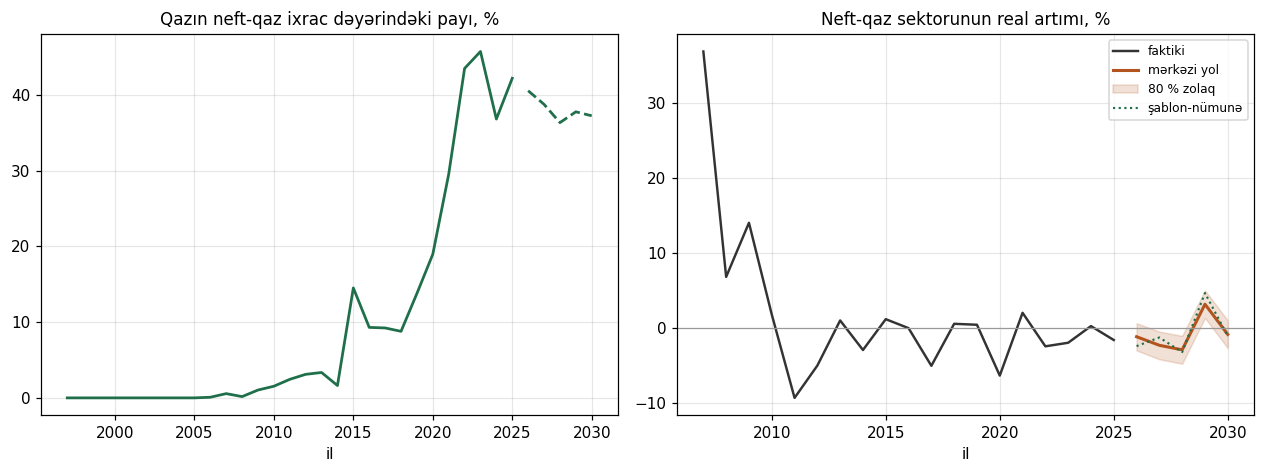

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
ax = axes[0]
ax.plot(B.index, (1 - B["w_oil_exp"]) * 100, lw=1.8, color="#1f6f4a")
ax.plot(FY, (1 - w_all.reindex(FY)) * 100, lw=1.8, ls="--", color="#1f6f4a")
ax.set_title("Qazın neft-qaz ixrac dəyərindəki payı, %")
ax.set_xlabel("il")
ax = axes[1]
hist_g = VG["y"]
ax.plot(hist_g.index, hist_g.values, lw=1.6, color="#333333", label="faktiki")
ax.plot(FY, oil_g_fc.values, lw=2.0, color="#b3541e", label="mərkəzi yol")
ax.fill_between(FY, bands_og["lo80"], bands_og["hi80"], color="#b3541e", alpha=0.18,
                label="80 % zolaq")
ax.plot(FY, mb_oil.values, lw=1.4, ls=":", color="#1f6f4a", label="şablon-nümunə")
ax.axhline(0, color="#999999", lw=0.8)
ax.set_title("Neft-qaz sektorunun real artımı, %")
ax.set_xlabel("il"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. Nəticələrin ixracı

In [21]:
# --- 1. FƏRZİYYƏLƏR ---------------------------------------------------------------------------
rows_a = []
for y in FY:
    rows_a.append({"assumption_key": "oil_realg", "year": int(y), "value": float(oil_g_fc.loc[y]),
                   "unit": "%",
                   "note": "FR05b: əmtəəlik neft və qaz həcmlərinin dəyər çəkili indeksi "
                           "(həcm yolu — Nazirliyin hasilat planı)"})
    rows_a.append({"assumption_key": "oil_realg_lo80", "year": int(y),
                   "value": float(bands_og.loc[y, "lo80"]), "unit": "%",
                   "note": "80 % yelpik zolağının aşağı hüdudu (σ = ansamblın OOS RMSE-si)"})
    rows_a.append({"assumption_key": "oil_realg_hi80", "year": int(y),
                   "value": float(bands_og.loc[y, "hi80"]), "unit": "%",
                   "note": "80 % yelpik zolağının yuxarı hüdudu (σ = ansamblın OOS RMSE-si)"})
    rows_a.append({"assumption_key": "oilgas_pw_g", "year": int(y), "value": float(dpw_fc.loc[y]),
                   "unit": "%",
                   "note": "FR05b: ixrac dəyəri ilə çəkilənmiş neft+qaz qiymət indeksinin artımı"})
    rows_a.append({"assumption_key": "gas_export_price", "year": int(y),
                   "value": float(p_gas_fc.loc[y]), "unit": "USD/min m³",
                   "note": "FR05b ansamblı (AR(1), qaz/Brent nisbəti, ECM) — sınaqda saxlanılan modellər"})
    rows_a.append({"assumption_key": "oilgas_w_oil", "year": int(y),
                   "value": float(w_all.loc[y]), "unit": "pay",
                   "note": "FR05b: neftin neft+qaz ixrac dəyərindəki payı — çəkili qiymət "
                           "indeksinin çəkisi"})
outputs.write_assumptions(pd.DataFrame(rows_a))
print(f"assumptions.csv: {len(rows_a)} sətir yazıldı "
      f"({', '.join(sorted(set(r['assumption_key'] for r in rows_a)))})")

assumptions.csv: 30 sətir yazıldı (gas_export_price, oil_realg, oil_realg_hi80, oil_realg_lo80, oilgas_pw_g, oilgas_w_oil)


In [22]:
# --- 2. UZUN FORMATLI PROQNOZ -----------------------------------------------------------------
SER = {
    "oilgas_q_oil_mkt": ("Əmtəəlik neft hasilatı", "mln ton", q_oil_all, "natural"),
    "oilgas_q_oil_exp": ("Neft ixracı — həcm", "mln ton", q_oil_exp_all, "natural"),
    "oilgas_q_oil_dom": ("Neftin daxili bazara verilməsi", "mln ton", q_oil_dom_all, "natural"),
    "oilgas_q_gas_mkt": ("Əmtəəlik qaz hasilatı", "mlrd m³", q_gas_all, "natural"),
    "oilgas_q_gas_exp": ("Qaz ixracı — həcm", "mlrd m³", q_gas_exp_all, "natural"),
    "oilgas_q_gas_dom": ("Qazın daxili bazara verilməsi", "mlrd m³", q_gas_dom_all, "natural"),
    "oilgas_p_gas_exp": ("Qazın ixrac qiyməti", "USD/min m³", p_gas_all, "cari"),
    "oilgas_p_oil_exp": ("Neftin ixrac qiyməti", "USD/barel",
                         pd.concat([B["p_oil_exp"].dropna(), p_oil_exp_fc]).sort_index(), "cari"),
    "oilgas_w_gas_exp": ("Qazın neft-qaz ixrac dəyərindəki payı", "%", (1 - w_all) * 100, "indeks"),
    "oilgas_pw_g": ("Çəkilənmiş neft-qaz ixrac qiyməti indeksinin artımı", "%", dpw_all, "indeks"),
    "oilgas_volg": ("Neft-qaz əmtəəlik həcm indeksinin artımı", "%", gv_all, "indeks"),
    "oilgas_volg_lo5": ("Həcm indeksinin artımı — plan həcmləri 5 % aşağı (həssaslıq)", "%",
                        gv_lo5, "indeks"),
    "oilgas_volg_hi5": ("Həcm indeksinin artımı — plan həcmləri 5 % yuxarı (həssaslıq)", "%",
                        gv_hi5, "indeks"),
    "oilgas_go_nom": ("Neft-qaz hasilatı üzrə buraxılış (qurulmuş)", "mln AZN", go_nom, "cari"),
    "oilgas_va_nom": ("Neft-qaz hasilatı üzrə əlavə dəyər (qurulmuş)", "mln AZN", va_nom, "cari"),
}
rows_f = []
for code, (nm, unit, ser, _pb) in SER.items():
    s = pd.Series(ser).dropna()
    for y, v in s.items():
        y = int(y)
        if y > config.LAST_FORECAST:
            continue
        kind = "actual" if y <= LA else "forecast"
        rows_f.append({"fr": FR, "series_code": code, "series_name_az": nm, "unit": unit,
                       "year": y, "kind": kind, "source": "ours", "value": float(v),
                       "lo80": None, "hi80": None, "lo50": None, "hi50": None})
# real artımın zolağı ayrıca sıra kimi (FR01 `oil_realg`-i nəşr edir; burada blokun öz oxunuşu)
for y in FY:
    rows_f.append({"fr": FR, "series_code": "oilgas_realg", "series_name_az":
                   "Neft-qaz sektorunun real artımı — neft-qaz blokundan", "unit": "%",
                   "year": int(y), "kind": "forecast", "source": "ours",
                   "value": float(oil_g_fc.loc[y]), "lo80": float(bands_og.loc[y, "lo80"]),
                   "hi80": float(bands_og.loc[y, "hi80"]), "lo50": float(bands_og.loc[y, "lo50"]),
                   "hi50": float(bands_og.loc[y, "hi50"])})
for y, v in VG["y"].items():
    rows_f.append({"fr": FR, "series_code": "oilgas_realg", "series_name_az":
                   "Neft-qaz sektorunun real artımı — neft-qaz blokundan", "unit": "%",
                   "year": int(y), "kind": "actual", "source": "ours", "value": float(v),
                   "lo80": None, "hi80": None, "lo50": None, "hi50": None})
for y in FY:      # şablon-nümunə ssenarisi — yalnız müqayisə üçün
    rows_f.append({"fr": FR, "series_code": "oilgas_realg", "series_name_az":
                   "Neft-qaz sektorunun real artımı — neft-qaz blokundan", "unit": "%",
                   "year": int(y), "kind": "forecast", "source": "template_sample",
                   "value": float(mb_oil.loc[y]), "lo80": None, "hi80": None,
                   "lo50": None, "hi50": None})
fl = outputs.write_forecast_long(pd.DataFrame(rows_f))
print(f"forecast_long.csv: {FR} üzrə {len(rows_f)} sətir yazıldı; faylda cəmi {len(fl)} sətir")

forecast_long.csv: FR5B üzrə 416 sətir yazıldı; faylda cəmi 14603 sətir


In [23]:
# --- 3. TƏNLİKLƏR KATALOQU --------------------------------------------------------------------
SH = "Neft-Qaz sektoru"
cat_rows = [
    res_vg.catalog_row(
        eq_name="FR5b_neft_qaz_real_artim",
        description=("STRUKTUR: neft-qaz real artımı — əmtəəlik neft və qaz həcmlərinin əvvəlki il "
                     "qiymətləri ilə çəkilənmiş Laspeyres indeksi; sabit hədd sıfırdan fərqli deyil"),
        lhs="oil_realg", series_code="oil_realg", fr=FR, workbook=WB, sheet=SH,
        rhs="çəkili həcm indeksi (əmtəəlik neft, əmtəəlik qaz)"),
    res_gp_ar1.catalog_row(
        eq_name="FR5b_qaz_qiymeti_ar1",
        description="ETALON: qazın ixrac qiyməti — loq səviyyədə AR(1) orta qiymətə qayıdış",
        lhs="ln(oilgas_p_gas_exp)", series_code="oilgas_p_gas_exp", fr=FR, workbook=WB, sheet=SH),
    {"workbook": WB, "sheet": SH, "eq_name": "FR5b_qaz_qiymeti_ecm",
     "description": ("STRUKTUR: qazın ixrac qiyməti — Brent ilə xəta korreksiyası modeli (ECM); "
                     f"uzunmüddətli elastiklik {float(ecm_gp.lr.params['lb']):.3f}, "
                     f"düzəliş sürəti {float(ecm_gp.alpha):.3f}"),
     "lhs": "Δln(oilgas_p_gas_exp)", "rhs": "Δln(brent_usd) + xəta korreksiyası həddi",
     "series_code": "oilgas_p_gas_exp", "fr": FR,
     "sample_start": int(GP.index.min()) + 1, "sample_end": int(GP.index.max()),
     "adj_r2": round(float(ecm_gp.sr.adj_r2), 4), "se_regression": round(float(ecm_gp.sr.sigma), 4)},
    {"workbook": WB, "sheet": SH, "eq_name": "FR5b_qaz_qiymeti_nisbet",
     "description": ("KALİBRLƏMƏ: qazın ixrac qiyməti = qaz/Brent nisbətinin son beş illik ortası "
                     f"({ratio5_gp:.3f}) × Brent; sınaqda ən aşağı RMSE-ni verən model"),
     "lhs": "oilgas_p_gas_exp", "rhs": "brent_usd × nisbət(5 il)", "series_code": "oilgas_p_gas_exp",
     "fr": FR, "sample_start": int(GP.index.max()) - 4, "sample_end": int(GP.index.max()),
     "adj_r2": None, "se_regression": None},
    {"workbook": WB, "sheet": SH, "eq_name": "FR5b_neft_ixrac_qiymeti_nisbet",
     "description": ("KALİBRLƏMƏ: neftin ixrac qiyməti = Brent × nisbətin son beş illik ortası "
                     f"({RATIO_OIL_EXP:.4f}); yalnız buraxılışın manatla dəyərləndirilməsində "
                     "işlədilir, çəkili qiymət indeksinə daxil deyil"),
     "lhs": "oilgas_p_oil_exp", "rhs": "brent_usd × nisbət(5 il)", "series_code": "oilgas_p_oil_exp",
     "fr": FR, "sample_start": LA - 4, "sample_end": LA, "adj_r2": None, "se_regression": None},
    {"workbook": WB, "sheet": SH, "eq_name": "FR5b_cekili_qiymet_indeksi",
     "description": ("EYNİLİK: d(t) = w(t−1)·[P_neft(t)/P_neft(t−1)] + "
                     "(1−w(t−1))·[P_qaz(t)/P_qaz(t−1)] − 1; w — neftin ixrac dəyərindəki payı"),
     "lhs": "oilgas_pw_g", "rhs": "brent_usd, oilgas_p_gas_exp, ixrac dəyəri çəkiləri",
     "series_code": "oilgas_pw_g", "fr": FR,
     "sample_start": int(dpw.dropna().index.min()), "sample_end": LA,
     "adj_r2": None, "se_regression": None},
    {"workbook": WB, "sheet": "Mədənçıxarma", "eq_name": "FR5b_elave_deyer_payi_rho",
     "description": (f"KALİBRLƏMƏ: ρ = əlavə dəyər ÷ buraxılış, {int(rho.index.min())}–"
                     f"{int(rho.index.max())} müşahidələri {rho.min():.3f}–{rho.max():.3f} "
                     f"aralığındadır; proqnoz üfüqü üçün son üç ilin ortası {RHO_FC:.4f}"),
     "lhs": "oilgas_va_nom", "rhs": "oilgas_go_nom × ρ", "series_code": "oilgas_va_nom", "fr": FR,
     "sample_start": int(rho.index.min()), "sample_end": int(rho.index.max()),
     "adj_r2": None, "se_regression": None},
]
ec = outputs.write_equations_catalog(pd.DataFrame(cat_rows))
display(ec[ec["fr"] == FR][["eq_name", "lhs", "rhs", "sample_start", "sample_end", "adj_r2"]])

# --- 4. SINAQ NƏTİCƏLƏRİ ----------------------------------------------------------------------
bt_out = outputs.write_backtest(pd.concat([bt_og.table, bt_gp.table], ignore_index=True))
print(f"validation_backtest.csv: {len(bt_og.table) + len(bt_gp.table)} sətir yazıldı; "
      f"faylda cəmi {len(bt_out)} sətir")

# --- 5. SIRA LÜĞƏTİ ---------------------------------------------------------------------------
EN = {"oilgas_q_oil_mkt": "Marketable crude oil output", "oilgas_q_oil_exp": "Crude oil exports, volume",
      "oilgas_q_oil_dom": "Crude oil delivered to the domestic market",
      "oilgas_q_gas_mkt": "Marketable natural gas output", "oilgas_q_gas_exp": "Gas exports, volume",
      "oilgas_q_gas_dom": "Gas delivered to the domestic market",
      "oilgas_p_gas_exp": "Gas export price", "oilgas_p_oil_exp": "Crude oil export price", "oilgas_w_gas_exp": "Gas share of oil-gas export value",
      "oilgas_pw_g": "Value-weighted oil-gas export price index, growth",
      "oilgas_volg": "Oil-gas marketable volume index, growth",
      "oilgas_volg_lo5": "Volume index growth — plan volumes 5% lower (sensitivity)",
      "oilgas_volg_hi5": "Volume index growth — plan volumes 5% higher (sensitivity)",
      "oilgas_go_nom": "Oil-gas extraction gross output (constructed)",
      "oilgas_va_nom": "Oil-gas extraction value added (constructed)",
      "oilgas_realg": "Oil-gas sector real growth, from the oil-gas block"}
_CONSTRUCTED = {
    "oilgas_go_nom": ("QURULMUŞ kəmiyyət, müşahidə DEYİL: dörd ayağın (neft/qaz × ixrac/daxili) "
                      "həcm × qiymət cəmi. `Mədənçıxarma` vərəqinin müşahidə olunan buraxılış "
                      "sətri (`mine_r008`, 2016-2025) ilə fərqi ölçülüb: orta |fərq| 6,5 %, "
                      "maksimal 22,3 % (2023). Tarixi sətirlər `kind=actual` etiketi daşıyır, "
                      "çünki sıra bütün illərdə EYNİ konstruksiya ilə qurulur (2025/2026 "
                      "sərhədində qırılma olmasın deyə); müşahidə sırası bu koda YAZILMIR."),
    "oilgas_va_nom": ("QURULMUŞ kəmiyyət, müşahidə DEYİL: qurulmuş buraxılış × ρ. Müşahidə "
                      "olunan `mine_r009` ilə fərq buraxılışınkı ilə eynidir (orta 6,5 %, "
                      "maksimal 22,3 %). ρ müşahidə pəncərəsində interpolyasiya olunur, "
                      "proqnoz sabiti yalnız üfüqdə tətbiq edilir."),
}
dict_rows = [{"series_code": c, "name_az": SER[c][0], "name_en": EN[c], "unit": SER[c][1],
              "fr": FR,
              "statutory_sheet_ref": ("Neft-Qaz sektoru / Mədənçıxarma"
                                      + ("; " + _CONSTRUCTED[c] if c in _CONSTRUCTED else "")),
              "price_basis": SER[c][3]} for c in SER]
dict_rows.append({"series_code": "oilgas_realg",
                  "name_az": "Neft-qaz sektorunun real artımı — neft-qaz blokundan",
                  "name_en": EN["oilgas_realg"], "unit": "%", "fr": FR,
                  "statutory_sheet_ref": "8 vərəq, 2.4.1.1.", "price_basis": "indeks"})
sd = outputs.write_series_dictionary(pd.DataFrame(dict_rows))
print(f"series_dictionary.csv: {len(dict_rows)} sıra qeydiyyata alındı; faylda cəmi {len(sd)} sətir")

,eq_name,lhs,rhs,sample_start,sample_end,adj_r2
369,FR5b_cekili_qiymet_indeksi,oilgas_pw_g,"brent_usd, oilgas_p_gas_exp, ixrac dəyəri çəki...",1998,2025,NaN
370,FR5b_elave_deyer_payi_rho,oilgas_va_nom,oilgas_go_nom × ρ,2016,2025,NaN
371,FR5b_neft_ixrac_qiymeti_nisbet,oilgas_p_oil_exp,brent_usd × nisbət(5 il),2021,2025,NaN
372,FR5b_neft_qaz_real_artim,oil_realg,"çəkili həcm indeksi (əmtəəlik neft, əmtəəlik qaz)",2007,2025,0.9705
373,FR5b_qaz_qiymeti_ar1,ln(oilgas_p_gas_exp),l1,2007,2025,0.4740
374,FR5b_qaz_qiymeti_ecm,Δln(oilgas_p_gas_exp),Δln(brent_usd) + xəta korreksiyası həddi,2007,2025,0.4504
375,FR5b_qaz_qiymeti_nisbet,oilgas_p_gas_exp,brent_usd × nisbət(5 il),2021,2025,NaN


validation_backtest.csv: 90 sətir yazıldı; faylda cəmi 6747 sətir
series_dictionary.csv: 16 sıra qeydiyyata alındı; faylda cəmi 681 sətir


### 8.1 Yoxlama

In [24]:
v = validate.Verifier("FR05b — neft-qaz bloku")

# eyniliklər hər il üçün
_o = B.dropna(subset=["q_oil_mkt", "q_oil_exp"])
v.identity("neft: əmtəəlik = daxili + ixrac (tarixi)", _o["q_oil_mkt"],
           _o["q_oil_dom"] + _o["q_oil_exp"], tol=1e-9)
_g = B.dropna(subset=["q_gas_mkt", "q_gas_exp"])
v.identity("qaz: əmtəəlik = daxili + ixrac (tarixi)", _g["q_gas_mkt"],
           _g["q_gas_dom"] + _g["q_gas_exp"], tol=1e-9)
v.identity("neft: əmtəəlik = daxili + ixrac (proqnoz)", q_oil_mkt_fc,
           pd.Series({y: Q_OIL_DOM_FC for y in FY}) + q_oil_exp_fc, tol=1e-9)
v.identity("qaz: əmtəəlik = daxili + ixrac (proqnoz)", q_gas_mkt_fc,
           pd.Series({y: Q_GAS_DOM_FC for y in FY}) + q_gas_exp_fc, tol=1e-9)
v.identity("buraxılış = dörd ayağın cəmi", go_nom.dropna(),
           go_parts.sum(axis=1, min_count=1).dropna(), tol=1e-9)

# fərziyyə faylı geri oxunur
asm = outputs.read_assumptions()
v.identity("fərziyyə: oil_realg = mərkəzi yol", asm["oil_realg"].reindex(FY), oil_g_fc, tol=1e-9)
v.identity("fərziyyə: oilgas_pw_g = çəkili indeks", asm["oilgas_pw_g"].reindex(FY), dpw_fc, tol=1e-9)
v.identity("fərziyyə: gas_export_price = ansambl", asm["gas_export_price"].reindex(FY), p_gas_fc,
           tol=1e-9)
v.identity("fərziyyə: oilgas_w_oil = ixrac dəyəri çəkisi", asm["oilgas_w_oil"].reindex(FY),
           w_all.reindex(FY), tol=1e-9)
v.ok("assumptions.csv-də yeganə oil_realg yolu",
     int((pd.read_csv(config.ASSUMPTIONS)["assumption_key"] == "oil_realg").sum()) == len(FY))

# uzun formatlı fayl diskdən oxunur
_fl = pd.read_csv(outputs.FORECAST_LONG_PATH)
_b = _fl[(_fl.fr == FR) & (_fl.source == "ours")]
v.identity("forecast_long: oilgas_pw_g proqnoz sətirləri = hesablanmış indeks",
           _b[(_b.series_code == "oilgas_pw_g") & (_b.kind == "forecast")].set_index("year")["value"],
           dpw_fc, tol=1e-9)
v.identity("forecast_long: əmtəəlik neft faktiki sətirləri = məlumat qatı",
           _b[(_b.series_code == "oilgas_q_oil_mkt") & (_b.kind == "actual")].set_index("year")["value"],
           B["q_oil_mkt"].dropna(), tol=1e-9)

# yelpik zolağının sıralanması
v.ok("yelpik zolağı düzgün sıralanıb (lo80 ≤ lo50 ≤ mərkəz ≤ hi50 ≤ hi80)",
     bool((bands_og.lo80 <= bands_og.lo50).all() and (bands_og.lo50 <= oil_g_fc).all()
          and (oil_g_fc <= bands_og.hi50).all() and (bands_og.hi50 <= bands_og.hi80).all()))

# qiymətləndirmə nümunələri proqnoz üfüqünə toxunmur
v.no_lookahead("həcm tənliyinin nümunəsi", VG.index)
v.no_lookahead("qaz qiyməti nümunəsi", GP.index)
v.no_lookahead("real artımın sınaq pəncərəsi", pd.Index(bt_og.common_years))
v.no_lookahead("qaz qiymətinin sınaq pəncərəsi", pd.Index(bt_gp.common_years))

# müstəqil yenidən hesablama: çəkili indeks ilkin sıralardan
def _yeniden_indeks():
    bb = data_layer.oilgas_block()
    out = {}
    for t in range(2007, LA + 1):
        w = float(bb.loc[t - 1, "w_oil_exp"])
        ro = float(bb.loc[t, "p_brent"]) / float(bb.loc[t - 1, "p_brent"])
        rg = float(bb.loc[t, "p_gas_exp"]) / float(bb.loc[t - 1, "p_gas_exp"])
        out[t] = (w * ro + (1 - w) * rg - 1) * 100
    return pd.Series(out)

v.recompute("çəkili qiymət indeksi 2007–%d" % LA, shipped=dpw.loc[2007:LA], fn=_yeniden_indeks,
            tol=1e-9)

# müstəqil yenidən hesablama: 2026-cı ilin həcm indeksi
def _yeniden_hecm2026():
    y0, y1 = LA, FY[0]
    po = float(B.loc[y0, "p_oil_azn_t"]); pg = float(B.loc[y0, "p_gas_azn_km3"])
    num = float(q_oil_mkt_fc.loc[y1]) * po + float(q_gas_mkt_fc.loc[y1]) * pg
    den = float(B.loc[y0, "q_oil_mkt"]) * po + float(B.loc[y0, "q_gas_mkt"]) * pg
    return (num / den - 1) * 100

v.recompute("həcm indeksi 2026", shipped=float(gv_fc.loc[FY[0]]), fn=_yeniden_hecm2026, tol=1e-9)

v.assert_all()

  YOXLAMA: FR05b — neft-qaz bloku
  [PASS] eynilik: neft: əmtəəlik = daxili + ixrac (tarixi)
         20 il, maksimal fərq 0.000e+00
  [PASS] eynilik: qaz: əmtəəlik = daxili + ixrac (tarixi)
         20 il, maksimal fərq 0.000e+00
  [PASS] eynilik: neft: əmtəəlik = daxili + ixrac (proqnoz)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: qaz: əmtəəlik = daxili + ixrac (proqnoz)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: buraxılış = dörd ayağın cəmi
         34 il, maksimal fərq 0.000e+00
  [PASS] eynilik: fərziyyə: oil_realg = mərkəzi yol
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: fərziyyə: oilgas_pw_g = çəkili indeks
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: fərziyyə: gas_export_price = ansambl
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: fərziyyə: oilgas_w_oil = ixrac dəyəri çəkisi
         5 il, maksimal fərq 0.000e+00
  [PASS] assumptions.csv-də yeganə oil_realg yolu
  [PASS] eynilik: forecast_long: oilgas_pw_g proqnoz 

## 9. Məhdudiyyətlər

**Həcm yolu hələ də plandan gəlir.** Blok real artımı hesablayır, lakin proqnoz illərinin
həcmləri Nazirliyin hasilat planından götürülür. Rəsmi hasilat proqnozu və onun daxili/ixrac
bölgüsü daxil olduqda bu iki giriş birbaşa əvəzlənir; blokun tənlikləri dəyişmir. Sınaq rəqəmi
(ansamblın etalona nisbətdə bacarığı) məhz bu şərtlə oxunmalıdır: **həcm yolu bilindiyi halda**
real artımın dəqiqliyi ölçülür.

**Daxili həcmlərin fərziyyəsi.** Proqnoz üfüqündə daxili bazara verilən neft və qaz həcmi son
faktiki ilin səviyyəsində saxlanılır və ixrac qalıq kimi alınır. Bu, açıq fərziyyədir; daxili
tələbin öz tənliyi qurulmayıb, çünki daxili satış həcmləri üzrə ayrıca sıra yoxdur.

**DATA-GAP: daxili qiymətlər.** Neft və qazın daxili bazar qiymətləri heç bir statistik nəşrdə
verilmir. Buraxılışın daxili ayaqları Nazirliyin öz nümunə iş kitabındakı qiymətləndirmə ilə
(53,6 AZN/ton və 44,87 AZN/min m³) hesablanır və **TƏSDİQLƏNMƏMİŞ** sayılır; tənzimlənən satış
tarifi sıraları məlumat sorğusundadır. Blokun iki mərkəzi konstruksiyası — çəkili qiymət indeksi
və əmtəəlik həcm indeksi — bu qiymətlərdən asılı deyil.

**DATA-GAP: neftin ixrac həcmi 2016-dan əvvəl.** İş kitabının 5-ci sətri əmtəəlik hasilatla
uzlaşmır (Bölmə 2.1). Ona görə daxili/ixrac bölgüsü yalnız 2016-dan etibarən nəşr olunur və
2008-ci ilin qiymət müşahidəsi çəkili indeksin neft ayağında işlədilmir.

**Qazın ixrac qiyməti qısa nümunə üzərində qurulur.** Sıra 2006-dan başlayır və 2021–2023-cü
illərin Avropa epizodu nümunənin böyük hissəsini təşkil edir; ansamblın OOS RMSE-si səviyyənin
təxminən yarısı qədərdir. Bu, qiymətin özünün qeyri-müəyyənliyidir və zolaqda göstərilir.
Müqavilə səviyyəsində qiymət yolları (Nazirliyin nümunə iş kitabının `O&G` vərəqi, 53–56-cı
sətirlər: ixrac qiyməti, Şahdəniz və SOCAR üzrə ayrıca sıralar, daxili qiymət) həmin faylda
mövcuddur və Bölmə 5.2-də dəstəkləyici sübut kimi çap olunur: qiymət iki fərqli müqavilə rejiminə
bölünür. Həmin sıralar **yalnız oxunub, modelə daxil edilməyib**, çünki fayl nümunə-model faylıdır
və onun 2024-dən sonrakı sütunları proyeksiyadır; rejim bölgüsünün özü isə blokun niyə qaz ayağını
ayrıca daşıdığını izah edir.

**Neftin ixrac qiyməti proqnozda kalibrlənmiş nisbətlə alınır.** Faktiki ixrac qiyməti ilə Brent
arasındakı nisbət 2011-ci ildən bəri 1,01 ətrafında dayanıqlıdır və proqnozda son beş ilin ortası
tətbiq olunur. Bu, tənlik deyil, kalibrləmədir; onun yeganə funksiyası 2025-ci ilin faktiki qiyməti
ilə proqnoz illərinin qiyməti arasında ölçü bazasını qorumaqdır. Çəkili qiymət indeksi bu
kalibrləmədən asılı deyil — orada neft ayağı həm tarixdə, həm proqnozda Brent-dir.

**Qurulmuş buraxılış müşahidə olunan sətirdən 6,5 % (orta) fərqlənir.** Blok neft-qaz
buraxılışını dörd ayağın (neft/qaz × ixrac/daxili) həcm × qiymət cəmi kimi qurur; `Mədənçıxarma`
vərəqinin öz buraxılış sətri (`mine_r008`) isə müstəqil müşahidədir. İki kəmiyyət 2016–2025-də
orta hesabla **6,5 %**, ən çox isə **22,3 %** (2023-cü il) fərqlənir. Fərq daxili qiymət
fərziyyəsindən gəlmir — onun həssaslığı 2,3 %-dir; mənbəyi ixrac sətirləri ilə mədənçıxarma
vərəqinin buraxılış sətri arasındakı vintaj/əhatə fərqidir. Nəticənin iki oxunuşu var və hər
ikisi açıq deyilməlidir: (i) blokun **mərkəzi konstruksiyaları** — çəkili qiymət indeksi və
əmtəəlik həcm indeksi — bu fərqdən asılı DEYİL, çünki onlar nisbətlərdir və səviyyə
kalibrləməsindən keçmir; (ii) lakin nəşr olunan `oilgas_go_nom` və `oilgas_va_nom` **səviyyə**
sıralarıdır və onların tarixi sətirləri `kind="actual"` etiketi daşıyır, halbuki dəyər
qurulmuşdur, müşahidə deyil. Etiket saxlanılır ki, sıra bütün illərdə eyni konstruksiya ilə
getsin və 2025/2026 sərhədində qırılma olmasın (paketin FR02-də tətbiq etdiyi eyni qayda), lakin
fərqin ölçüsü indi həm icra çıxışında, həm seriya lüğətində yazılır. Müşahidə sırasının özü bu
kodlara yazılmır.

**ρ sabit götürülür.** Əlavə dəyər payı 2016–2025-ci illərdə 0,91–0,94 aralığındadır və proqnoz
üfüqündə son üç ilin ortası ilə saxlanılır. Payın özünün tənliyi qurulmayıb: on müşahidə
davranış tənliyi üçün kifayət deyil.